### Dengue & Weather in Bangladesh 

Questions:
1. The worst dengue year?
2. The most dangerous month?
3. Is the "average" telling the truth?
4. Does dengue come with the rain, or after it?
5. What does a 15-year dengue calender look like?
6. We can build in interactive report?

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px


In [2]:
df = pd.read_csv("dengue.csv")

In [3]:
df.head()

,YEAR,MONTH,MIN,MAX,HUMIDITY,RAINFALL,DENGUE
0,2008,1,10.2,25.1,78.8,39.9,0
1,2008,2,9.1,26.4,72.6,19.9,0
2,2008,3,15.8,31.4,76.9,30.2,0
3,2008,4,19.0,34.0,73.9,29.4,0
4,2008,5,21.1,34.2,77.4,217.7,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   YEAR      180 non-null    int64  
 1   MONTH     180 non-null    int64  
 2   MIN       180 non-null    float64
 3   MAX       180 non-null    float64
 4   HUMIDITY  180 non-null    float64
 5   RAINFALL  180 non-null    float64
 6   DENGUE    180 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 10.0 KB


In [6]:
df.describe().round(2)

,YEAR,MONTH,MIN,MAX,HUMIDITY,RAINFALL,DENGUE
count,180.00,180.00,180.00,180.00,180.00,180.00,180.00
mean,2015.00,6.50,18.63,31.56,80.08,194.32,1225.40
std,4.33,3.46,5.56,3.01,5.21,198.55,4913.79
min,2008.00,1.00,6.20,24.20,67.50,0.00,0.00
25%,2011.00,3.75,13.68,30.10,76.97,12.68,5.50
50%,2015.00,6.50,19.90,32.40,80.50,148.70,55.50
75%,2019.00,9.25,23.90,33.45,84.70,318.55,293.50
max,2022.00,12.00,26.30,37.00,88.10,881.30,52636.00


In [7]:
df.value_counts('YEAR')

YEAR
2008    12
2009    12
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
Name: count, dtype: int64

In [8]:
df.groupby('YEAR').size()

YEAR
2008    12
2009    12
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
dtype: int64

In [10]:
df.rename(columns={
    'YEAR':'year',
    'MONTH':'month', 
    'MIN':'min', 
    'MAX':'max', 
    'HUMIDITY':'humidity', 
    'RAINFALL':'rainfall', 
    'DENGUE':'dengue'}, inplace=True)

In [11]:
df.head()

,year,month,min,max,humidity,rainfall,dengue
0,2008,1,10.2,25.1,78.8,39.9,0
1,2008,2,9.1,26.4,72.6,19.9,0
2,2008,3,15.8,31.4,76.9,30.2,0
3,2008,4,19.0,34.0,73.9,29.4,0
4,2008,5,21.1,34.2,77.4,217.7,0


In [15]:
df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))

In [16]:
df.head()

,year,month,min,max,humidity,rainfall,dengue,date
0,2008,1,10.2,25.1,78.8,39.9,0,2008-01-01
1,2008,2,9.1,26.4,72.6,19.9,0,2008-02-01
2,2008,3,15.8,31.4,76.9,30.2,0,2008-03-01
3,2008,4,19.0,34.0,73.9,29.4,0,2008-04-01
4,2008,5,21.1,34.2,77.4,217.7,0,2008-05-01


In [17]:
yearly_rain = df.groupby('year')['rainfall'].sum().reset_index()

In [19]:
yearly_rain.max()

year        2022.0
rainfall    3071.3
dtype: float64

In [20]:
yearly_rain.min()

year        2008.0
rainfall    1837.0
dtype: float64

In [21]:
yearly_rain.mean()

year        2015.0
rainfall    2331.8
dtype: float64

In [22]:
df['rainfall'].max()

881.3

In [23]:
df.head()

,year,month,min,max,humidity,rainfall,dengue,date
0,2008,1,10.2,25.1,78.8,39.9,0,2008-01-01
1,2008,2,9.1,26.4,72.6,19.9,0,2008-02-01
2,2008,3,15.8,31.4,76.9,30.2,0,2008-03-01
3,2008,4,19.0,34.0,73.9,29.4,0,2008-04-01
4,2008,5,21.1,34.2,77.4,217.7,0,2008-05-01


In [25]:
# temperature
df['temp_avg'] = round((df['min'] + df['max']) / 2, 1)

In [27]:
df.head()

,year,month,min,max,humidity,rainfall,dengue,date,temp_avg
0,2008,1,10.2,25.1,78.8,39.9,0,2008-01-01,17.6
1,2008,2,9.1,26.4,72.6,19.9,0,2008-02-01,17.8
2,2008,3,15.8,31.4,76.9,30.2,0,2008-03-01,23.6
3,2008,4,19.0,34.0,73.9,29.4,0,2008-04-01,26.5
4,2008,5,21.1,34.2,77.4,217.7,0,2008-05-01,27.6


In [29]:
def get_season(month):
    if month in [3, 4, 5]:
        return 'Pre Monsoon'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month in [10, 11]:
        return 'Post Monsoon'
    else:
        return 'Winter'
    
df['season'] = df['month'].apply(get_season)

In [30]:
df.head()

,year,month,min,max,humidity,rainfall,dengue,date,temp_avg,season
0,2008,1,10.2,25.1,78.8,39.9,0,2008-01-01,17.6,Winter
1,2008,2,9.1,26.4,72.6,19.9,0,2008-02-01,17.8,Winter
2,2008,3,15.8,31.4,76.9,30.2,0,2008-03-01,23.6,Pre Monsoon
3,2008,4,19.0,34.0,73.9,29.4,0,2008-04-01,26.5,Pre Monsoon
4,2008,5,21.1,34.2,77.4,217.7,0,2008-05-01,27.6,Pre Monsoon


Q1. Worst dengue year?

In [33]:
yearly = df.groupby('year')['dengue'].sum()
yearly.sort_values(ascending=False).head(3)

year
2019    101354
2022     61089
2021     28429
Name: dengue, dtype: int64

Q2. Which single month?

In [36]:
df.sort_values(by='dengue', ascending=False)[['date', 'dengue','rainfall']].head(3)

,date,dengue,rainfall
139,2019-08-01,52636,317.3
177,2022-10-01,21932,223.9
178,2022-11-01,19334,0.2


Q3. Mean vs. Median

In [37]:
print(f"Mean dengue cases: {df['dengue'].mean()}")
print(f"Median dengue cases: {df['dengue'].median()}")

Mean dengue cases: 1225.4
Median dengue cases: 55.5


Q4. Most dangerous month

In [41]:
by_month = df.groupby('month')['dengue'].mean().round(2)

In [42]:
by_month.sort_values(ascending=False).head(3)

month
8     4686.27
9     2814.87
10    2781.93
Name: dengue, dtype: float64

Q5. Share the cases in July-November

In [43]:
df.head()

,year,month,min,max,humidity,rainfall,dengue,date,temp_avg,season
0,2008,1,10.2,25.1,78.8,39.9,0,2008-01-01,17.6,Winter
1,2008,2,9.1,26.4,72.6,19.9,0,2008-02-01,17.8,Winter
2,2008,3,15.8,31.4,76.9,30.2,0,2008-03-01,23.6,Pre Monsoon
3,2008,4,19.0,34.0,73.9,29.4,0,2008-04-01,26.5,Pre Monsoon
4,2008,5,21.1,34.2,77.4,217.7,0,2008-05-01,27.6,Pre Monsoon


In [49]:
danger = df[(df['month'] >= 7) & (df['month'] <= 11)]

share = (danger['dengue'].sum() / df['dengue'].sum()) * 100

share = round(share, 1)
print(f"Dengue cases during July to November: {share}")

Dengue cases during July to November: 94.2


Q6. Cases by season

In [51]:
season_cases = df.groupby('season')['dengue'].sum()
season_cases.sort_values(ascending=False)

season
Monsoon         139729
Post Monsoon     71884
Winter            7849
Pre Monsoon       1110
Name: dengue, dtype: int64

case per year (matplotlib)

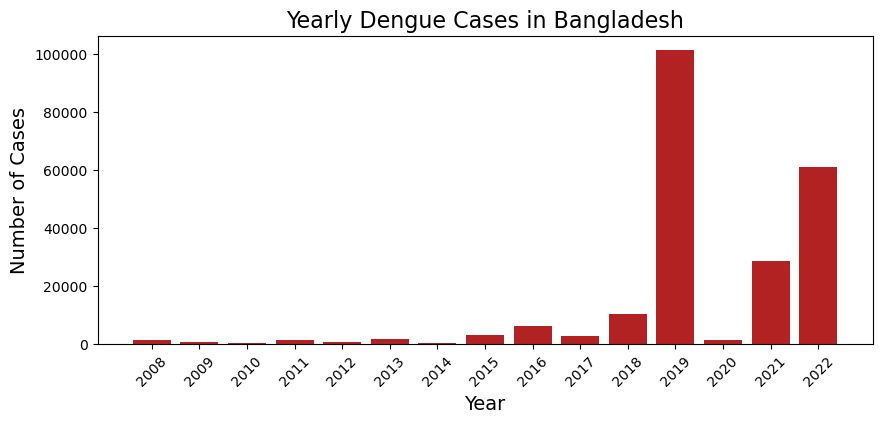

In [58]:
plt.figure(figsize=(10, 4))
plt.bar(yearly.index, yearly.values, color='firebrick')
plt.title('Yearly Dengue Cases in Bangladesh', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Cases', fontsize=14)
plt.xticks(yearly.index, rotation=45)
plt.show()

Dengue calender (seaborn)

<Axes: xlabel='month', ylabel='year'>

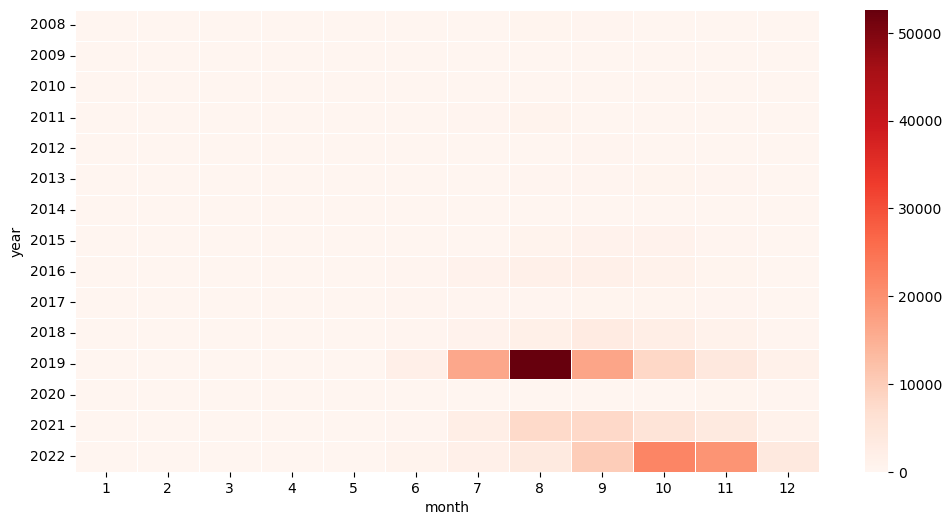

In [68]:
calender = df.pivot_table(index='year', columns='month', values='dengue', aggfunc='sum')

plt.figure(figsize=(12, 6))
sns.heatmap(calender, cmap='Reds', linewidths=0.5)

Calender with color capped at 5000

<Axes: xlabel='month', ylabel='year'>

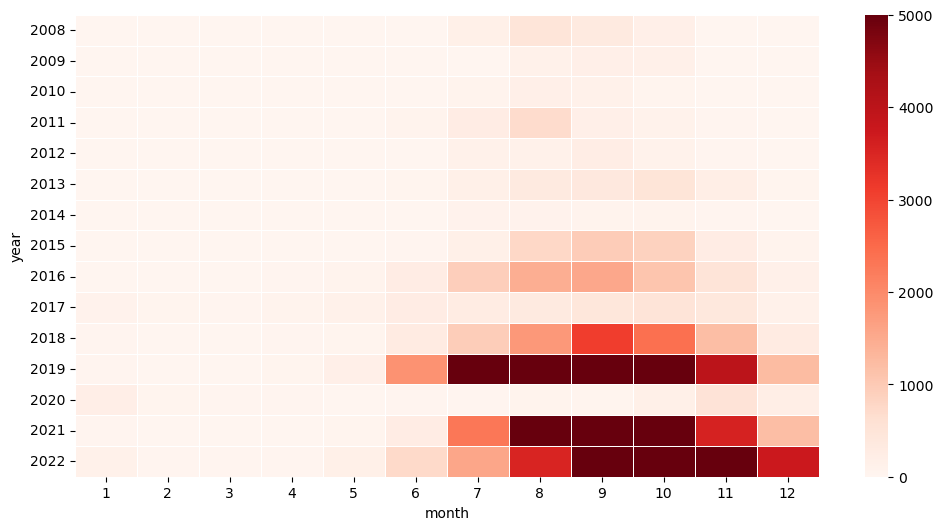

In [69]:
plt.figure(figsize=(12, 6))
sns.heatmap(calender, cmap='Reds', linewidths=0.5, vmax=5000)

Monthly average: rain and cases

In [73]:
monthly = df.groupby('month')[['rainfall', 'dengue']].mean().round(2)

In [74]:
monthly

,rainfall,dengue
month,,
1,7.85,36.47
2,15.95,11.60
3,29.29,10.40
4,105.70,17.20
5,266.19,46.40
6,445.33,259.13
7,525.45,1555.00
8,409.91,4686.27
9,300.69,2814.87


Rain vs. Dengue

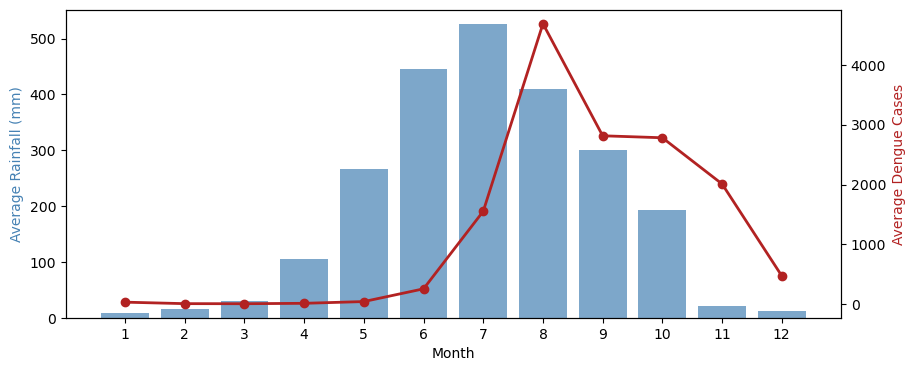

In [84]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(monthly.index, monthly['rainfall'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Rainfall (mm)', color='steelblue')
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['dengue'], color='firebrick', marker='o', linewidth=2)
ax2.set_ylabel('Average Dengue Cases', color='firebrick')


plt.show()

Last month rain: shift(1)

In [86]:
monthly['rain_last_month'] = monthly['rainfall'].shift(1)

In [87]:
monthly

,rainfall,dengue,rain_last_month
month,,,
1,7.85,36.47,NaN
2,15.95,11.60,7.85
3,29.29,10.40,15.95
4,105.70,17.20,29.29
5,266.19,46.40,105.70
6,445.33,259.13,266.19
7,525.45,1555.00,445.33
8,409.91,4686.27,525.45
9,300.69,2814.87,409.91


Correlation: same month vs. month before

In [90]:
print(round(monthly['dengue'].corr(monthly['rainfall']), 2))
print(round(monthly['dengue'].corr(monthly['rain_last_month']), 2))

0.44
0.84


15 years of rain and dengue (two y-axis + range slider)

In [91]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [101]:
story = make_subplots(specs=[[{"secondary_y": True}]])

story.add_trace(go.Bar(
    x=df['date'],
    y=df['rainfall'],
    name='Rainfall',
    marker_color='steelblue',
    opacity=0.6
), secondary_y=False)

story.add_trace(go.Scatter(
    x=df['date'],
    y=df['dengue'],
    name='Dengue',
    line=dict(color='firebrick', width=2),
), secondary_y=True)

story.show()


c:\Users\rashe\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



Animation: one dengue season per year

In [109]:
season_anim = px.bar(df, x='month', y='dengue', color='season', range_y=[0, 53000], animation_frame='year', title='One dengue season per year')

season_anim.update_xaxes(tickmode='array',
                         ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
                         tickvals=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
season_anim.show()

save as html

In [111]:
story.write_html('Dengue report.html')